# Evaluación — Módulo de Interpolación y Aproximación

**Programación Científica 2026-1 · Universidad Nacional de Colombia**

mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

---

**Integrantes:** (orden alfabético)
- Apellido1, Nombre1: Castaño Juan
- Apellido2, Nombre2: Salcedo Santiago

---

## Instrucciones generales

**Duración:** 1.5 horas

**Recursos permitidos:** internet, LLMs, notebooks del curso. No pueden compartir código ni respuestas con otras parejas.

**Entrega — flujo GitHub obligatorio:**

0. Crear una copia de este archivo que se llama `apellido1_apellido2_evaluacion1.ipynb` en la carpeta EVALUACION y sobre ese archivo se harán todos los resultados/cambios/commits.

1. Crear una rama con el nombre exacto: `apellido1_apellido2_5Junio` (orden alfabético, minúsculas, sin tildes, sin espacios).

2. Trabajen **únicamente sobre esa rama**. Deben hacer **exactamente 3 commits** antes de abrir el PR.

3. Los mensajes de commit deben seguir esta convención y cubrir avance real:
   ```
   init: cedulas, seed y generacion de datos
   add: interpolacion spline y ajuste LS
   add: PCA y analisis escritos
   ```

4. Abran un **Pull Request** de su rama a `main`. En el título del PR escriban: `Evaluación [Apellido1] [Apellido2]`.

⚠️ **Penalizaciones automáticas:**
- Notebook que no ejecuta de principio a fin (`Kernel → Restart & Run All`): −10 pts.
- Menos o más de 3 commits: −5 pts.
- Rama con nombre incorrecto: −5 pts.

---

**Distribución de puntos:**

| Sección | Puntos |
|---|---|
| P0 — Inicialización y datos | 5 |
| P1 — Cuestionario conceptual | 20 |
| P2 — Interpolación B-spline 2D | 30 |
| P3 — Ajuste por mínimos cuadrados | 20 |
| P4 — PCA | 15 |
| GitHub (commits + PR + respuesta) | 10 |
| **Total** | **100** |

---
## P0 — Inicialización (5 pts)

Escriban sus números de cédula en las variables indicadas. **No modifiquen ninguna otra línea de esta sección.** Todos los datos del ejercicio se generan a partir de su semilla.

In [5]:
# TODO P0: reemplacen los ceros con sus ID reales
cedula1 = 1034991170
cedula2 = 903213

In [6]:
# 🔒 CELDA DE DATOS — no modificar
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from scipy.linalg import svd

assert cedula1 != 0 and cedula2 != 0, "Deben ingresar sus ID en la celda anterior."

seed = int((cedula1 + cedula2) % 1000)
rng  = np.random.default_rng(seed)

# Parámetros de la superficie — dependen de la semilla
alpha = 1.0 + (seed % 7)  * 0.3          # frecuencia en x: entre 1.0 y 2.8
beta  = 1.0 + (seed % 5)  * 0.4          # frecuencia en y: entre 1.0 y 2.6
gamma = 0.10 + (seed % 11) * 0.02        # decaimiento gaussiano: entre 0.10 y 0.30
noise_std = 0.05 + (seed % 13) * 0.01    # ruido: entre 0.05 y 0.17

# Malla gruesa de muestreo (15x15 puntos)
n  = 15
x_raw = np.linspace(-3, 3, n)
y_raw = np.linspace(-3, 3, n)
X_raw, Y_raw = np.meshgrid(x_raw, y_raw, indexing='ij')

# Elevación verdadera + ruido
Z_true = np.sin(alpha * X_raw) * np.cos(beta * Y_raw) * np.exp(-gamma * (X_raw**2 + Y_raw**2))
Z_data = Z_true + rng.normal(0, noise_std, X_raw.shape)

print(f"Semilla: {seed}")
print(f"Parámetros — alpha: {alpha:.2f}, beta: {beta:.2f}, gamma: {gamma:.3f}, ruido: {noise_std:.3f}")
print(f"Malla de datos: {n}x{n} puntos en [-3,3]x[-3,3]")
print(f"Z_data shape: {Z_data.shape}")

Semilla: 383
Parámetros — alpha: 2.50, beta: 2.20, gamma: 0.280, ruido: 0.110
Malla de datos: 15x15 puntos en [-3,3]x[-3,3]
Z_data shape: (15, 15)


---
## P1 — Cuestionario conceptual (20 pts)

Respondan las siguientes preguntas **sin ejecutar código adicional**. Basen sus respuestas en la lectura del bloque de generación de datos de P0.

### P1.1 (7 pts)

La celda de datos genera `Z_data = Z_true + ruido`. Cuando construyan el spline en P2, este va a **interpolar** `Z_data`, no `Z_true`.

**a)** ¿Qué significa que el spline interpole `Z_data` en lugar de ajustar `Z_true`? ¿El spline va a pasar exactamente por los valores de `Z_data`?  
**b)** ¿En qué condición sería preferible usar mínimos cuadrados en lugar del spline para reconstruir la superficie?

**Respuesta P1.1:**

a) Que el spline interpole Z_data significa que pasa exactamente por los valores observados incluyendo el ruido. Se sobreajusta a los datos reproduciendo el ruido como si fuera parte de los valores que queremos analizar. Y sí, pasa exactamente por los puntos de Z_data.

b) Con datos ruidosos es preferible mínimos cuadrados, porque este método se subajusta a los datos y así ignora el ruido.

### P1.2 (7 pts)

En P3 van a ajustar un plano $z = c_0 + c_1 x + c_2 y$ a los datos usando mínimos cuadrados.

**a)** ¿Cómo se construye la matriz $A$ del sistema $A\mathbf{c} = \mathbf{z}$ para este modelo? Descríbanla en términos de sus columnas.  
**b)** La función verdadera `Z_true` no es un plano. ¿Qué representa entonces el plano ajustado? ¿Qué información útil les da sobre la superficie?

**Respuesta P1.2:**

a) Bajo este modelo,construiremos una matriz A de 225 x 3, donde la primera columna contiene sólamente 1 en todas la entradas, la segunda contiene la coordenada x de todos los datos y la tercera contiene la coordenada y de los datos, puesta de tal manera que las coordenadas (x,y) de una fila correspondan a un punto del dataset (sin contar el 1).

b) Este plano representa la mejor aproximación lineal global de todos los datos según mínimos cuadrados. Este resultado se puede interpretar como un promedio de altura y direcciones entre todos los datos.

### P1.3 (6 pts)

En P4 van a aplicar PCA a la nube de puntos $(x_i, y_i, z_i)$ formada por los 225 puntos de la malla.

**a)** ¿Por qué es necesario centrar los datos antes de calcular los componentes principales?  
**b)** ¿Qué interpretación geométrica tiene el primer componente principal en el contexto de esta superficie?

**Respuesta P1.3:**

a) Es necesario pues en el proceso de PCA se tienen en cuenta los autovectores de la matriz de covarianza. Estos vectores sólo tienen sentido interpretativo como direcciones de dispersión de los datos si la nube de puntos se encuentra en el origen, ello pues si no estuviera en el origen, los autovectores apuntarían hacia la dirección general de la nube y no solo darían información de su dispersión.

b) La primera componente muestra la dirección en la que los datos varían más.

---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"
```

---
## P2 — Interpolación B-spline 2D (27 pts)

Usen `RectBivariateSpline` de `scipy.interpolate` para construir un spline bicúbico sobre los datos `(x_raw, y_raw, Z_data)`.

### P2.1 — Construcción y evaluación (15 pts)

Construyan el spline con `kx=3, ky=3` y evalúenlo en una malla fina de **100×100 puntos** en $[-3,3]\times[-3,3]$.

In [7]:
# TODO P2.1: construir el spline bicúbico y evaluar en malla fina

spline = RectBivariateSpline(x_raw, y_raw, Z_data, kx=3, ky=3)

n_fine = 100
x_fine = np.linspace(-3, 3, n_fine)
y_fine = np.linspace(-3, 3, n_fine)

Z_spline = spline(x_fine, y_fine)

X_fine, Y_fine = np.meshgrid(x_fine, y_fine, indexing='ij')

print(f"Spline bicúbico construido (kx=3, ky=3)")
print(f"Malla fina: {n_fine}x{n_fine} puntos en [-3,3]x[-3,3]")
print(f"Z_spline shape: {Z_spline.shape}")


Spline bicúbico construido (kx=3, ky=3)
Malla fina: 100x100 puntos en [-3,3]x[-3,3]
Z_spline shape: (100, 100)


### P2.2 — Figura comparativa (15 pts)

Produzcan una figura con **dos paneles side-by-side** (`subplot` 1×2):
- Panel izquierdo: `Z_data` en la malla gruesa (superficie en 3D).
- Panel derecho: superficie interpolada por el spline en la malla fina (3D).

Ambos paneles deben tener: colorbar, ejes etiquetados, y usar el **mismo colormap y los mismos límites de color** (`vmin`/`vmax` iguales en ambos).

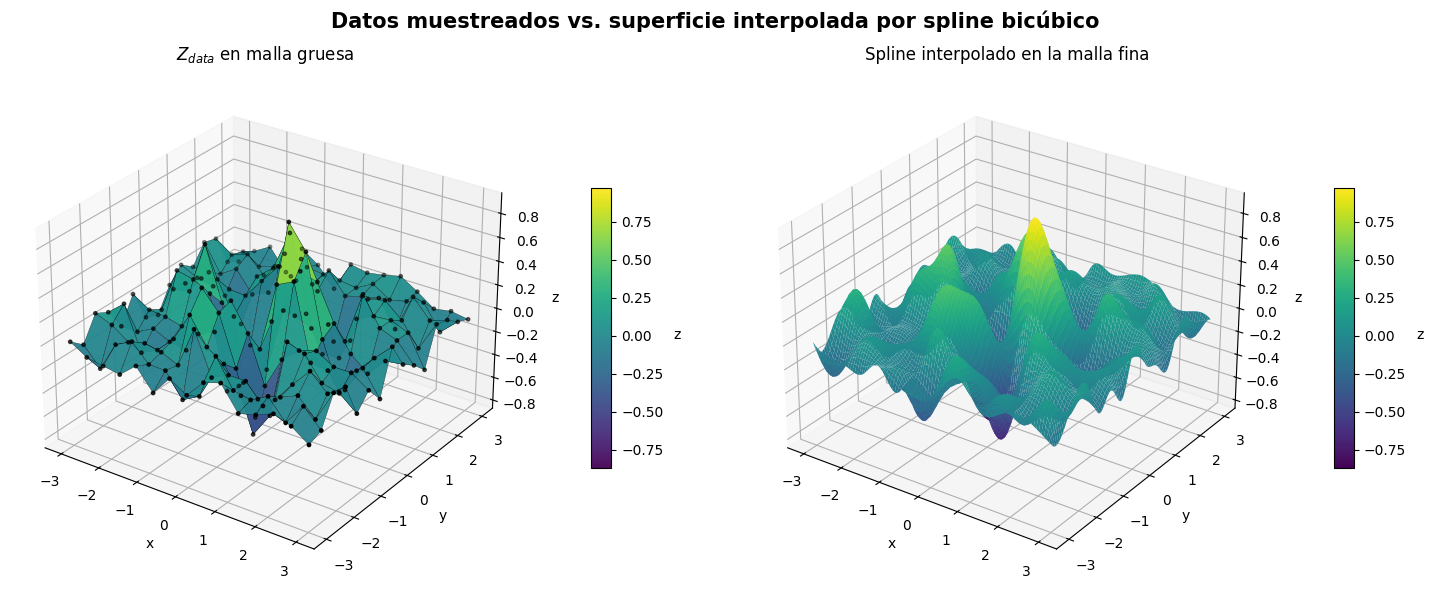

In [14]:
# TODO P2.2: figura comparativa datos vs spline

vmin = min(Z_data.min(), Z_spline.min())
vmax = max(Z_data.max(), Z_spline.max())
cmap = 'viridis'

fig = plt.figure(figsize=(15, 6))
fig.suptitle("Datos muestreados vs. superficie interpolada por spline bicúbico",
             fontsize=15, fontweight='bold', y=0.98)

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
s1 = ax1.plot_surface(X_raw, Y_raw, Z_data, cmap=cmap, vmin=vmin, vmax=vmax,
                      rstride=1, cstride=1, linewidth=0.2, edgecolor='k',
                      antialiased=True, alpha=0.95)
ax1.scatter(X_raw, Y_raw, Z_data, color='k', s=6, depthshade=True)
ax1.set_title(f"$Z_{{data}}$ en malla gruesa", fontsize=12, pad=10)
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")
ax1.set_zlim(vmin, vmax)
ax1.view_init(elev=28, azim=-55)
cb1 = fig.colorbar(s1, ax=ax1, shrink=0.55, aspect=14, pad=0.10)
cb1.set_label("z", rotation=0, labelpad=10)


ax2 = fig.add_subplot(1, 2, 2, projection='3d')
s2 = ax2.plot_surface(X_fine, Y_fine, Z_spline, cmap=cmap, vmin=vmin, vmax=vmax,
                      rstride=1, cstride=1, linewidth=0, antialiased=True)
ax2.set_title(f"Spline interpolado en la malla fina", fontsize=12, pad=10)
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("z")
ax2.set_zlim(vmin, vmax)
ax2.view_init(elev=28, azim=-55)
cb2 = fig.colorbar(s2, ax=ax2, shrink=0.55, aspect=14, pad=0.10)
cb2.set_label("z", rotation=0, labelpad=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


---
## P3 — Ajuste por mínimos cuadrados (20 pts)

Ajusten un **plano** $z = c_0 + c_1 x + c_2 y$ a los 225 puntos de la malla usando mínimos cuadrados. Trabajen con los datos ruidosos `Z_data`.

### P3.1 — Ajuste (10 pts)

Construyan la matriz $A$, resuelvan el sistema normal con `np.linalg.lstsq`, e impriman los coeficientes $c_0, c_1, c_2$ con 4 decimales.

In [12]:
# TODO P3.1: construcción de A y ajuste por mínimos cuadrados

x_flat = X_raw.ravel()
y_flat = Y_raw.ravel()
z_flat = Z_data.ravel()

A = np.column_stack([np.ones_like(x_flat), x_flat, y_flat])

coef, residuals, rank, svals = np.linalg.lstsq(A, z_flat, rcond=None)
c0, c1, c2 = coef

print(f"Matriz de diseño A: {A.shape}  (sistema sobredeterminado, rango {rank})")
print(f"c0 (término independiente) = {c0:.4f}")
print(f"c1 (pendiente en x)        = {c1:.4f}")
print(f"c2 (pendiente en y)        = {c2:.4f}")

Matriz de diseño A: (225, 3)  (sistema sobredeterminado, rango 3)
c0 (término independiente) = -0.0096
c1 (pendiente en x)        = -0.0012
c2 (pendiente en y)        = 0.0050


### P3.2 — Residuos y figura (10 pts)

Calculen el mapa de residuos: $R = Z_{\text{data}} - Z_{\text{plano}}$, donde $Z_{\text{plano}}$ es el plano evaluado en la malla gruesa.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: plano ajustado sobre la malla gruesa, con colorbar y ejes etiquetados.
- Panel derecho: mapa de residuos $R$, con colorbar, ejes etiquetados, y colormap **divergente** centrado en cero.

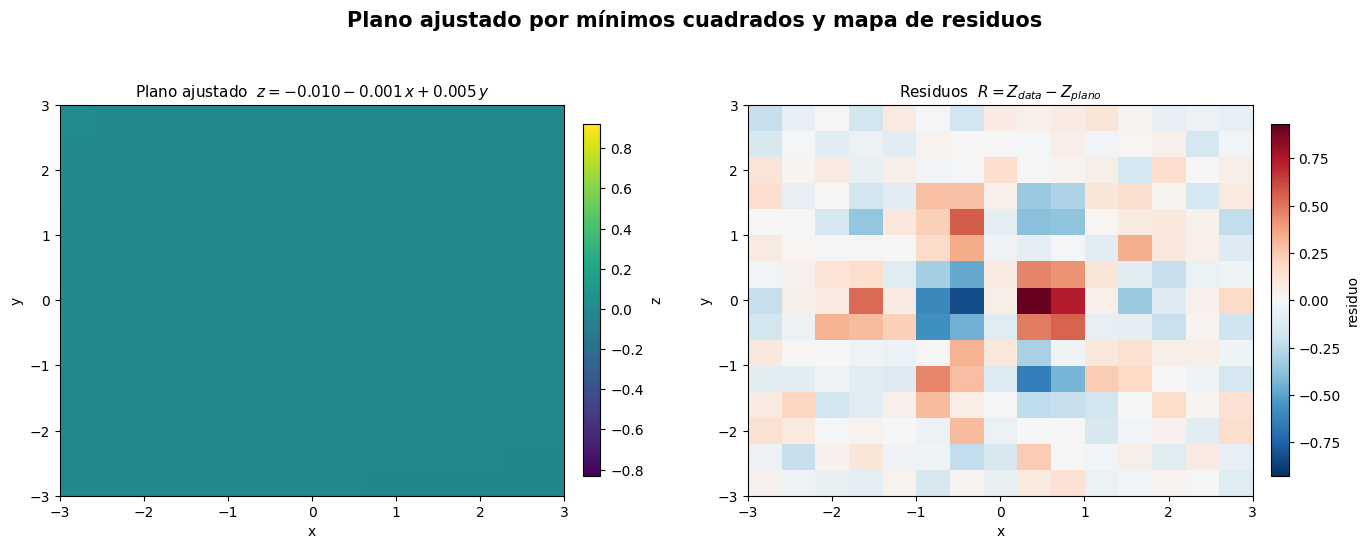

In [13]:


Z_plano = c0 + c1 * X_raw + c2 * Y_raw
R = Z_data - Z_plano

vmin_p = min(Z_plano.min(), Z_data.min())
vmax_p = max(Z_plano.max(), Z_data.max())

rmax = np.abs(R).max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("Plano ajustado por mínimos cuadrados y mapa de residuos",
             fontsize=15, fontweight='bold', y=0.99)

extent = [x_raw.min(), x_raw.max(), y_raw.min(), y_raw.max()]

im1 = ax1.imshow(Z_plano.T, origin='lower', extent=extent, cmap='viridis',
                 vmin=vmin_p, vmax=vmax_p, aspect='auto')
ax1.set_title(f"Plano ajustado  $z = {c0:.3f} {c1:+.3f}\\,x {c2:+.3f}\\,y$", fontsize=11)
ax1.set_xlabel("x"); ax1.set_ylabel("y")
cb1 = fig.colorbar(im1, ax=ax1, shrink=0.9, pad=0.03)
cb1.set_label("z")

im2 = ax2.imshow(R.T, origin='lower', extent=extent, cmap='RdBu_r',
                 vmin=-rmax, vmax=rmax, aspect='auto')
ax2.set_title("Residuos  $R = Z_{data} - Z_{plano}$", fontsize=11)
ax2.set_xlabel("x"); ax2.set_ylabel("y")
cb2 = fig.colorbar(im2, ax=ax2, shrink=0.9, pad=0.03)
cb2.set_label("residuo")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"
```

---
## P4 — PCA sobre señales sísmicas (15 pts)

Una red de 20 sensores sísmicos registra vibraciones del terreno durante 50 instantes
de tiempo. Las señales están contaminadas con ruido.

In [11]:
omega1 = 1.0 + (seed % 7) * 0.3
omega2 = 1.0 + (seed % 5) * 0.4

m, p = 20, 50
t = np.linspace(0, 2*np.pi, p)

rng2 = np.random.default_rng(seed + 1)
a = rng2.uniform(0.5, 2.0, m)
b = rng2.uniform(0.5, 2.0, m)

X = np.outer(a, np.cos(omega1 * t)) + np.outer(b, np.sin(omega2 * t))
X += rng.normal(0, 0.3, X.shape)

print(f"Señales: {m} sensores x {p} instantes")
print(f"omega1={omega1:.2f}, omega2={omega2:.2f}")

Señales: 20 sensores x 50 instantes
omega1=2.50, omega2=2.20


### P4.1 — Cálculo de componentes principales (7 pts)

Centren las filas de `X` y calculen la SVD con `np.linalg.svd`.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: varianza explicada por cada componente (gráfico de barras).
- Panel derecho: varianza acumulada vs k (puntos + línea), con una línea
  horizontal punteada en el 85%.

Ambos paneles con ejes etiquetados y título.

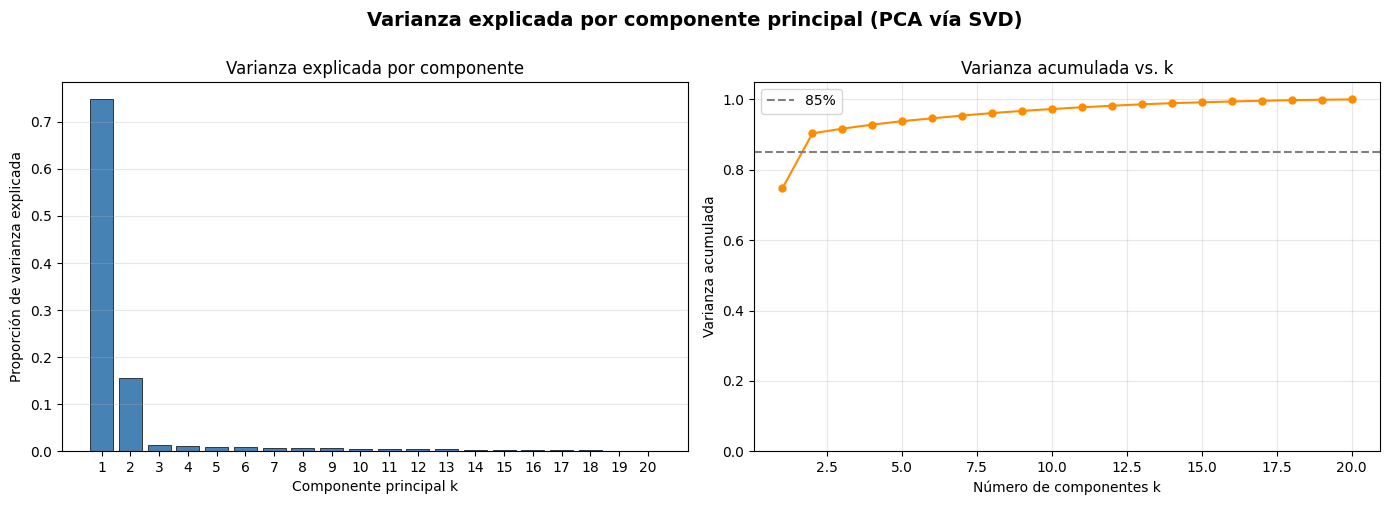

PC1 explica 74.78% de la varianza
PC2 explica 15.58% de la varianza
Acumulada con 2 componentes: 90.36%


In [15]:

X_centered = X - X.mean(axis=1, keepdims=True)

U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

var_explained  = S**2
var_ratio      = var_explained / var_explained.sum()
var_cumulative = np.cumsum(var_ratio)
k_comp         = np.arange(1, len(S) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Varianza explicada por componente principal (PCA vía SVD)",
             fontsize=14, fontweight='bold', y=1.0)

ax1.bar(k_comp, var_ratio, color='steelblue', edgecolor='k', linewidth=0.5)
ax1.set_xlabel("Componente principal k")
ax1.set_ylabel("Proporción de varianza explicada")
ax1.set_title("Varianza explicada por componente")
ax1.set_xticks(k_comp)
ax1.grid(axis='y', alpha=0.3)

ax2.plot(k_comp, var_cumulative, 'o-', color='darkorange', markersize=5)
ax2.axhline(0.85, ls='--', color='gray', label='85%')
ax2.set_xlabel("Número de componentes k")
ax2.set_ylabel("Varianza acumulada")
ax2.set_title("Varianza acumulada vs. k")
ax2.set_ylim(0, 1.05)
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Resumen numérico
print(f"PC1 explica {var_ratio[0]*100:.2f}% de la varianza")
print(f"PC2 explica {var_ratio[1]*100:.2f}% de la varianza")
print(f"Acumulada con 2 componentes: {var_cumulative[1]*100:.2f}%")

### P4.2 — Proyección en el espacio PCA (8 pts)

Calculen los scores proyectando las 20 señales centradas sobre los primeros k
componentes que explique más del 89% de la varianza (2 o 3).

Produzcan un scatter de los 20 sensores en el espacio de los primeros k PCs:
- Si k=2: scatter PC1 vs PC2, coloreado por índice de sensor, con colorbar
  y etiquetas de sensor en cada punto.
- Si k=3: tres paneles PC1 vs PC2, PC1 vs PC3, PC2 vs PC3.

En todos los casos: ejes etiquetados con el nombre del componente (`"PC1"`, `"PC2"`...),
líneas en cero, grid, título con el porcentaje de varianza acumulada capturada.

k elegido = 2  (varianza acumulada capturada: 90.36%)


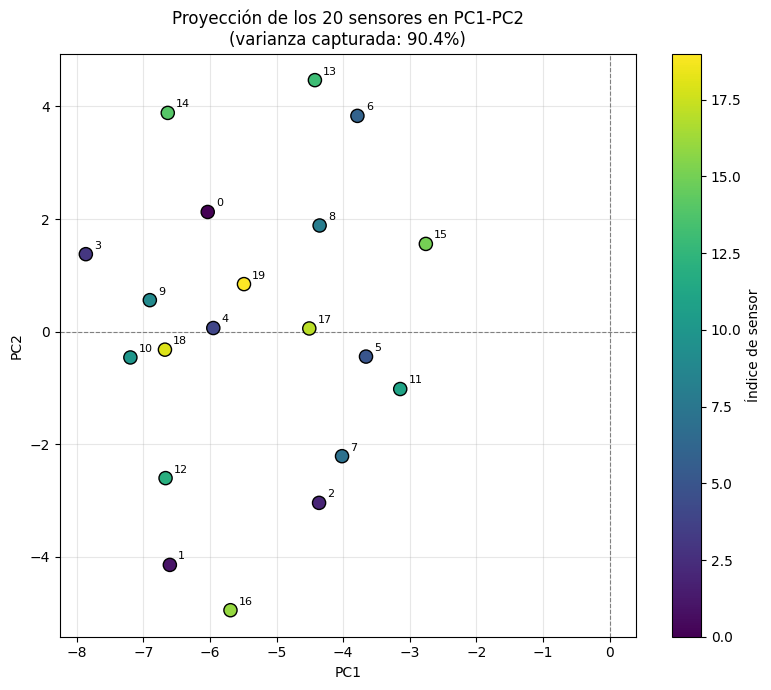

In [20]:
# P4.2: proyección de los 20 sensores en el espacio PCA

# Elegir el menor k cuya varianza acumulada supere el 89%
k = int(np.argmax(var_cumulative >= 0.89)) + 1
var_capt = var_cumulative[k-1] * 100
print(f"k elegido = {k}  (varianza acumulada capturada: {var_capt:.2f}%)")

# Scores = proyección de las señales centradas sobre los primeros k componentes.
# Las direcciones principales son las filas de Vt (vectores en el espacio temporal R^50).
scores = X_centered @ Vt[:k].T     # forma (20, k)

sensor_idx = np.arange(m)          # 0..19, para colorear cada sensor

if k == 2:
    fig, ax = plt.subplots(figsize=(8, 7))
    sc = ax.scatter(scores[:, 0], scores[:, 1], c=sensor_idx, cmap='viridis',
                    s=90, edgecolor='k', zorder=3)
    # etiqueta de sensor en cada punto
    for i in range(m):
        ax.annotate(str(i), (scores[i, 0], scores[i, 1]),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlabel(f"PC1")
    ax.set_ylabel(f"PC2")
    ax.set_title(f"Proyección de los 20 sensores en PC1-PC2\n"
                 f"(varianza capturada: {var_capt:.1f}%)")
    ax.grid(alpha=0.3)
    cb = fig.colorbar(sc, ax=ax)
    cb.set_label("Índice de sensor")
    plt.tight_layout()
    plt.show()

elif k == 3:
    pares = [(0, 1), (0, 2), (1, 2)]   # PC1-PC2, PC1-PC3, PC2-PC3
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    fig.suptitle(f"Proyección de los 20 sensores en el espacio PCA "
                 f"(varianza capturada: {var_capt:.1f}%)",
                 fontsize=14, fontweight='bold')
    for ax, (i, j) in zip(axes, pares):
        sc = ax.scatter(scores[:, i], scores[:, j], c=sensor_idx, cmap='viridis',
                        s=80, edgecolor='k', zorder=3)
        for s in range(m):
            ax.annotate(str(s), (scores[s, i], scores[s, j]),
                        textcoords="offset points", xytext=(5, 4), fontsize=7)
        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.axvline(0, color='gray', lw=0.8, ls='--')
        ax.set_xlabel(f"PC{i+1}")
        ax.set_ylabel(f"PC{j+1}")
        ax.set_title(f"PC{i+1} vs PC{j+1}")
        ax.grid(alpha=0.3)
    cb = fig.colorbar(sc, ax=axes, fraction=0.025, pad=0.02)
    cb.set_label("Índice de sensor")
    plt.show()

---
## GitHub (10 pts)

Esta sección se califica directamente desde el PR. No hay celdas adicionales.

**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"

# 4. Tercer commit — después de P4 y todos los análisis escritos
git add evaluacion_final_modulo.ipynb
git commit -m "add: PCA y analisis escritos"

# 5. Push y abrir PR
git push origin apellido1_apellido2_5Junio
```

Luego en GitHub: **New Pull Request** → base: `main` ← compare: `apellido1_apellido2_5Junio`.

Título del PR: `Evaluación [Apellido1] [Apellido2]`
